In [ ]:
--#import Libraries
import os
import torch
import torch.nn as nn
from torchvision import models
from transformers import ViTModel, ViTConfig
from torch import nn, optim
from tqdm import tqdm
from torchvision import models, transforms, datasets
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.metrics import classification_report,accuracy_score,f1_score
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- Cell 2: Dataset path ---
# Define dataset path (Warp-C only)
base_path = "/content/drive/MyDrive/WaRP/Warp-C"

train_dir = os.path.join(base_path, "train_crops")
test_dir  = os.path.join(base_path, "test_crops")


In [ ]:
# custom dataset
class CustomImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label



In [ ]:
# --- Cell 3: Transformations ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

In [ ]:
# --- Cell 4: Load Dataset and Create DataLoaders ---
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f" Loaded Warp-C dataset: {num_classes} classes")
print("Classes:", class_names)

# --- Cell: Check total samples in Warp-C dataset ---

# Total number of training samples
num_train_samples = len(train_dataset)

# Total number of testing samples
num_test_samples = len(test_dataset)

print(f"Total training samples in Warp-C dataset: {num_train_samples}")
print(f"Total testing samples in Warp-C dataset:  {num_test_samples}")

 Loaded Warp-C dataset: 5 classes
Classes: ['bottle', 'canister', 'cans', 'cardboard', 'detergent']
Total training samples in Warp-C dataset: 8823
Total testing samples in Warp-C dataset:  1551


Batch image tensor shape: torch.Size([16, 3, 224, 224])
Batch label tensor shape: torch.Size([16])
Unique labels in this batch: tensor([0, 1, 2, 3, 4])


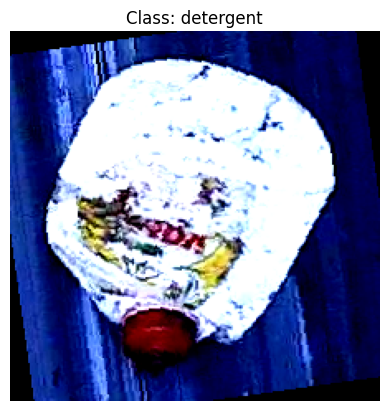

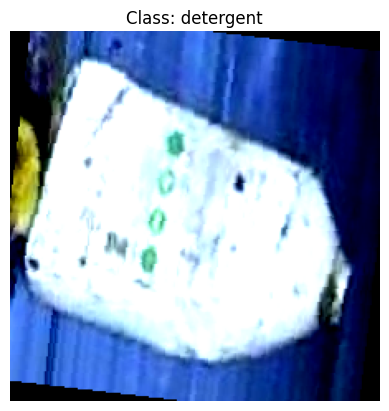

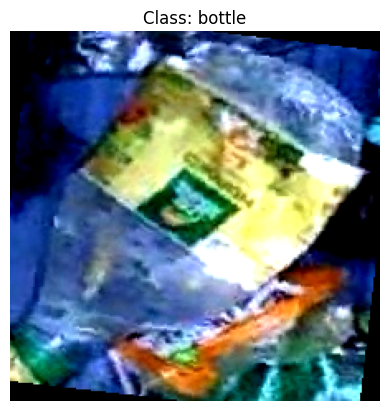

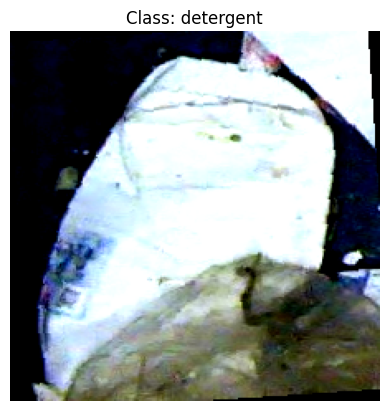

In [ ]:
# --- CELL 8: Check one batch from DataLoader ---
dataiter = iter(train_loader)
images, labels = next(dataiter)

print(f"Batch image tensor shape: {images.shape}")  # e.g., [32, 3, 224, 224]
print(f"Batch label tensor shape: {labels.shape}")
print(f"Unique labels in this batch: {torch.unique(labels)}")

# --- Show a few sample images with labels ---
def imshow(img, title):
    img = img * 0.5 + 0.5  # if normalized with mean=0.5, std=0.5
    img = torch.clamp(img, 0, 1)  # ensure values stay between [0,1]
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()

warp_c_train_path = "/content/drive/MyDrive/WaRP/Warp-C/train_crops"
class_names = sorted([d for d in os.listdir(warp_c_train_path) if os.path.isdir(os.path.join(warp_c_train_path, d))])

# Display first 4 images with their corresponding labels
for i in range(4):
    label_idx = labels[i].item()
    class_name = class_names[label_idx]
    imshow(images[i], f"Class: {class_name}")


In [ ]:
# model builiding
class HybridResNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridResNetViT, self).__init__()

        # ResNet18 backbone
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet.fc = nn.Identity()  # remove final classification layer
        resnet_dim = 512

        # ViT backbone
        vit_config = ViTConfig.from_pretrained("google/vit-base-patch16-224")
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224", config=vit_config)
        vit_dim = vit_config.hidden_size  # typically 768

        # Fusion + classifier
        self.classifier = nn.Sequential(
            nn.Linear(resnet_dim + vit_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_features = self.resnet(x)                     # [B, 512]
        vit_features = self.vit(pixel_values=x).pooler_output # [B, 768]
        combined = torch.cat((resnet_features, vit_features), dim=1)
        out = self.classifier(combined)
        return out

# Initialize hybrid model
model = HybridResNetViT(num_classes=num_classes)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(" Hybrid ResNet18 + ViT model initialized on:", device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 198MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


 Hybrid ResNet18 + ViT model initialized on: cuda


In [ ]:
# --- Cell 7: Optimizer and Loss ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(" Loss function and optimizer ready!")



 Loss function and optimizer ready!


In [ ]:
# --- Cell 4: Model Training (Warp-C full dataset) ---
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

train_losses = []
model.train()

total_train_samples = len(train_loader.dataset)
print(f"Total training samples per epoch: {total_train_samples}")

for epoch in range(num_epochs):
    running_loss = 0.0
    processed = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        processed += len(images)

        # Show live progress percentage
        percent = (processed / total_train_samples) * 100
        print(f"\rEpoch [{epoch+1}/{num_epochs}] — {percent:.1f}% complete", end="")

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"\nEpoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")

print("\n Training complete. Model has seen all Warp-C samples in each epoch.")


Total training samples per epoch: 8823
Epoch [1/5] — 100.0% complete
Epoch [1/5] - Loss: 0.3857
Epoch [2/5] — 100.0% complete
Epoch [2/5] - Loss: 0.2084
Epoch [3/5] — 100.0% complete
Epoch [3/5] - Loss: 0.1324
Epoch [4/5] — 100.0% complete
Epoch [4/5] - Loss: 0.1079
Epoch [5/5] — 100.0% complete
Epoch [5/5] - Loss: 0.0844

 Training complete. Model has seen all Warp-C samples in each epoch.


In [ ]:
 # draw model diagram
# input size and output size of each layer


In [ ]:
# --- Cell 5: Model Testing (Warp-C full dataset) ---

model.eval()
all_preds = []
all_labels = []

total_test_samples = len(test_loader.dataset)
print(f"Total testing samples: {total_test_samples}")

correct = 0
processed = 0

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        processed += len(images)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Progress display
        percent = (processed / total_test_samples) * 100
        print(f"\rEvaluating model — {percent:.1f}% complete", end="")

Total testing samples: 1551
Evaluating model — 100.0% complete

In [ ]:
# --- Cell: Accuracy ---
accuracy = accuracy_score(all_labels, all_preds) * 100
print(f" Overall Test Accuracy: {accuracy:.2f}%")

 Overall Test Accuracy: 92.39%


In [ ]:
# --- Cell: F1 Score ---
f1 = f1_score(all_labels, all_preds, average='macro') * 100
print(f" Overall Macro F1-Score: {f1:.2f}")

 Overall Macro F1-Score: 86.66


In [ ]:
# --- Cell: Classification Report ---
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)
class_acc = (np.diag(cm) / cm.sum(axis=1)) * 100  # per-class accuracy

# Compute sensitivity (recall), precision, and F1-score
report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

# Specificity calculation
specificity = []
for i in range(len(class_names)):
    tn = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    fp = cm[:, i].sum() - cm[i, i]
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity.append(spec * 100)

# Create formatted DataFrame
table_data = []
for i, cls in enumerate(class_names):
    metrics = report_dict[cls]
    table_data.append({
        "Classes": cls,
        "Acc (%)": round(class_acc[i], 2),
        "Pre (%)": round(metrics["precision"] * 100, 2),
        "Sen (%)": round(metrics["recall"] * 100, 2),
        "F1 (%)": round(metrics["f1-score"] * 100, 2),
        "Spe (%)": round(specificity[i], 2)
    })

df_metrics = pd.DataFrame(table_data)

# Weighted Average Row
weighted_avg = report_dict["weighted avg"]
df_metrics.loc[len(df_metrics)] = {
    "Classes": "Weighted Average",
    "Acc (%)": round(np.mean(class_acc), 2),
    "Pre (%)": round(weighted_avg["precision"] * 100, 2),
    "Sen (%)": round(weighted_avg["recall"] * 100, 2),
    "F1 (%)": round(weighted_avg["f1-score"] * 100, 2),
    "Spe (%)": round(np.mean(specificity), 2)
}

# Format numbers and alignment for a clean display
styled_table = df_metrics.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]).hide(axis='index').format({
    "Acc (%)": "{:.2f}",
    "Pre (%)": "{:.2f}",
    "Sen (%)": "{:.2f}",
    "F1 (%)": "{:.2f}",
    "Spe (%)": "{:.2f}"
})

# Display as publication-style table
print("\n Performance Analysis of ResNet18 Model on WaRP-C Dataset:\n")
display(styled_table)



 Performance Analysis of ResNet18 Model on WaRP-C Dataset:



Classes,Acc (%),Pre (%),Sen (%),F1 (%),Spe (%)
bottle,96.78,95.24,96.78,96.00,87.56
canister,86.67,92.86,86.67,89.66,99.87
cans,88.78,84.47,88.78,86.57,98.90
cardboard,83.33,87.10,83.33,85.17,98.56
detergent,72.22,80.00,72.22,75.91,98.15
Weighted Average,85.55,92.25,92.39,92.29,96.61


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total testing samples: 1551
Evaluating model — 100.0% complete
Evaluation complete.


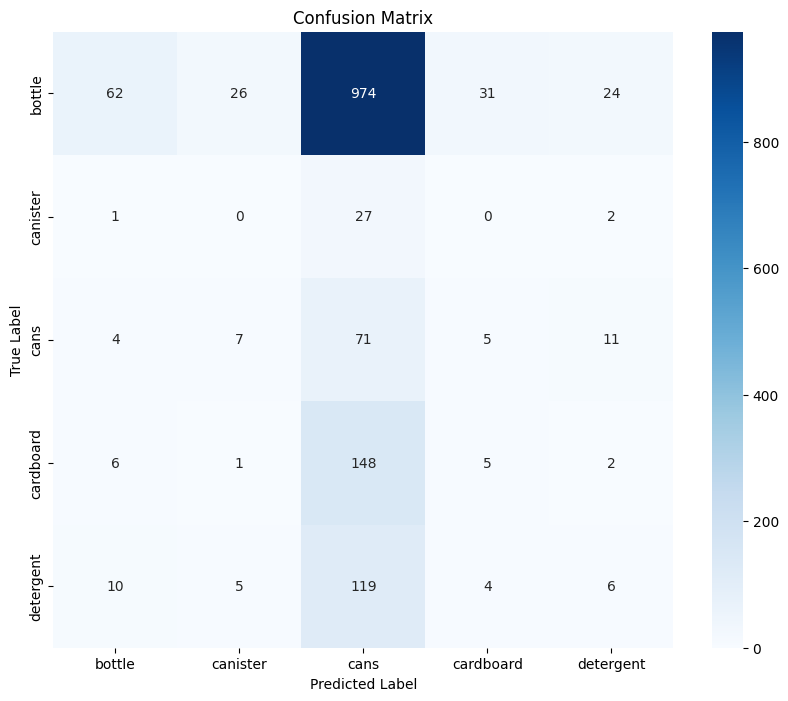

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import torch
from torch import nn, optim
from torchvision import models, transforms, datasets # Added transforms, datasets
from transformers import ViTModel, ViTConfig
import os # Added os for path operations
from torch.utils.data import DataLoader # Added DataLoader
from google.colab import drive # Added for drive mounting

# Remount Google Drive to ensure access, as FileNotFoundError occurred
drive.mount('/content/drive')

# Define the HybridResNetViT class here to ensure it's in scope
class HybridResNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridResNetViT, self).__init__()

        # ResNet18 backbone
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.resnet.fc = nn.Identity()  # remove final classification layer
        resnet_dim = 512

        # ViT backbone
        vit_config = ViTConfig.from_pretrained("google/vit-base-patch16-224")
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224", config=vit_config)
        vit_dim = vit_config.hidden_size  # typically 768

        # Fusion + classifier
        self.classifier = nn.Sequential(
            nn.Linear(resnet_dim + vit_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_features = self.resnet(x)                     # [B, 512]
        vit_features = self.vit(pixel_values=x).pooler_output # [B, 768]
        combined = torch.cat((resnet_features, vit_features), dim=1)
        out = self.classifier(combined)
        return out

# --- Start of additions to define test_loader and its dependencies ---
# Define dataset path (Warp-C only) - From cell KDuIwGSu7Hvn
base_path = "/content/drive/MyDrive/WaRP/Warp-C"
train_dir = os.path.join(base_path, "train_crops")
test_dir  = os.path.join(base_path, "test_crops")

# Add an explicit check for directory existence before proceeding
if not os.path.isdir(test_dir):
    raise FileNotFoundError(f"Directory not found: {test_dir}. Please ensure your Google Drive is mounted correctly and the path exists.")

# Transformations - From cell pV9hPsJrvlQJ
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

# Load Dataset and Create DataLoaders - From cell T5Gq8uN2iVdn
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['test'])
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
# --- End of additions ---

# Ensure num_classes is defined
# This assumes test_loader.dataset is an ImageFolder dataset or similar with a .classes attribute
if 'num_classes' not in globals() and 'num_classes' not in locals():
    if hasattr(test_loader.dataset, 'classes'): # test_loader.dataset is already ImageFolder
        num_classes = len(test_loader.dataset.classes)
    else:
        # Fallback if the structure is different, though previous cells imply ImageFolder
        raise ValueError("Could not determine num_classes. Ensure test_loader.dataset.classes is accessible.")

# Initialize model if it's not defined or re-initialize to ensure it uses the defined class
# If a trained model state dict was saved, it should be loaded here.
if 'model' not in locals() and 'model' not in globals():
    model = HybridResNetViT(num_classes=num_classes)
else:
    # If model exists, ensure it's an instance of HybridResNetViT and re-initialize if necessary
    # This part depends on whether the original `model` was already correctly initialized
    if not isinstance(model, HybridResNetViT):
        model = HybridResNetViT(num_classes=num_classes)
    # If it was, we assume its state was preserved after training, so no re-initialization needed

# Define device if not already in scope
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # Ensure model is on the correct device

# Ensure model is in evaluation mode
model.eval()

# Initialize lists to store predictions and labels
all_preds = []
all_labels = []

# Total number of testing samples
total_test_samples = len(test_loader.dataset)
print(f"Total testing samples: {total_test_samples}")

processed = 0

with torch.no_grad(): # Disable gradient calculations
    for batch_idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        processed += len(images)
        # Progress display
        percent = (processed / total_test_samples) * 100
        print(f"\rEvaluating model \u2014 {percent:.1f}% complete", end="")

print("\nEvaluation complete.")

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Ensure class_names is available (defined in previous cells, but adding a check for robustness)
if 'class_names' not in globals():
    # This assumes test_loader.dataset was created earlier. Adjust if your setup is different.
    class_names = test_loader.dataset.classes # Access classes from ImageFolder dataset

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()